In [70]:
from MLPKAN import MLPKAN
from kan import KAN
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

In [71]:
seed = 500
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

def rmse(y_true, y_pred):
    return torch.sqrt(torch.mean((y_true - y_pred) ** 2)).item()

model = MLPKAN(input_size=2, hidden_sizes=[3], output_size=2, subnetworkshape=[3,3])
print(model)



MLPKAN(
  (layers): ModuleList(
    (0): ModuleDict(
      (subnet_0_0): subnetwork(
        (layers): ModuleList(
          (0): Linear(in_features=1, out_features=3, bias=True)
          (1): ReLU()
          (2): Linear(in_features=3, out_features=3, bias=True)
          (3): ReLU()
          (4): Linear(in_features=3, out_features=1, bias=True)
        )
      )
      (subnet_0_1): subnetwork(
        (layers): ModuleList(
          (0): Linear(in_features=1, out_features=3, bias=True)
          (1): ReLU()
          (2): Linear(in_features=3, out_features=3, bias=True)
          (3): ReLU()
          (4): Linear(in_features=3, out_features=1, bias=True)
        )
      )
      (subnet_0_2): subnetwork(
        (layers): ModuleList(
          (0): Linear(in_features=1, out_features=3, bias=True)
          (1): ReLU()
          (2): Linear(in_features=3, out_features=3, bias=True)
          (3): ReLU()
          (4): Linear(in_features=3, out_features=1, bias=True)
        )
      )

In [72]:
x = torch.randn(1000, 2)
# .expand(-1, 2)
# x = torch.linspace(-100, 100, steps=1000).unsqueeze(1)
output = model(x)

RMSE between KAN and MLPKAN: 0.000979426084086299


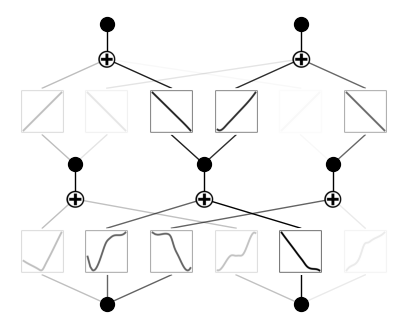

In [73]:
kan = KAN(width=[2,3,2], seed=seed, grid=5, auto_save=False, symbolic_enabled=False)
kan.set_splines_MLPKAN(x, model)
kan.plot()
rmse_value = rmse(kan(x), model(x))
print(f"RMSE between KAN and MLPKAN: {rmse_value}")

In [74]:
# import matplotlib.pyplot as plt

# # Get predictions from both models
# kan_output = kan(x).detach()
# mlpkan_output = model(x).detach()

# # Sort by x values for proper plotting
# sorted_indices = torch.argsort(x.squeeze())
# x_sorted = x[sorted_indices].numpy()
# kan_sorted = kan_output[sorted_indices].numpy()
# mlpkan_sorted = mlpkan_output[sorted_indices].numpy()

# # Create the plot
# plt.figure(figsize=(10, 6))
# plt.plot(x_sorted, kan_sorted, label='KAN', linewidth=2)
# plt.plot(x_sorted, mlpkan_sorted, label='MLPKAN', linewidth=2)
# plt.xlabel('x')
# plt.ylabel('Output')
# plt.title('KAN vs MLPKAN Output Comparison')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

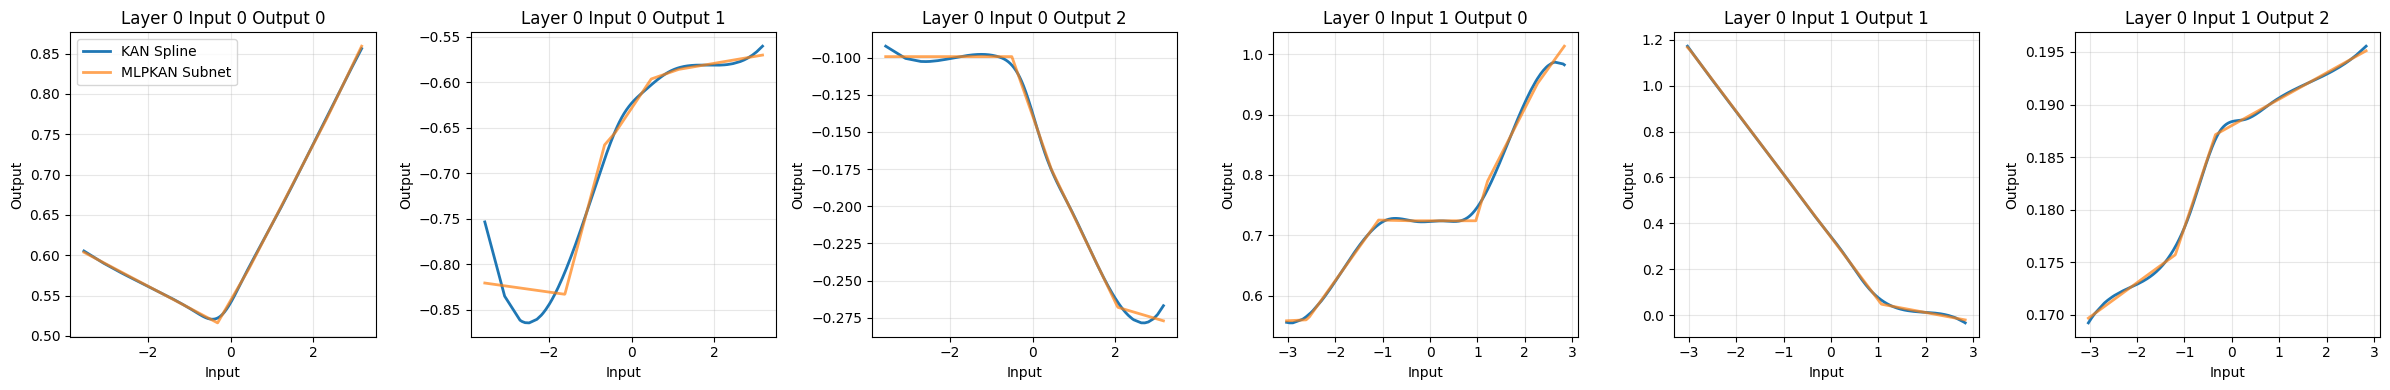

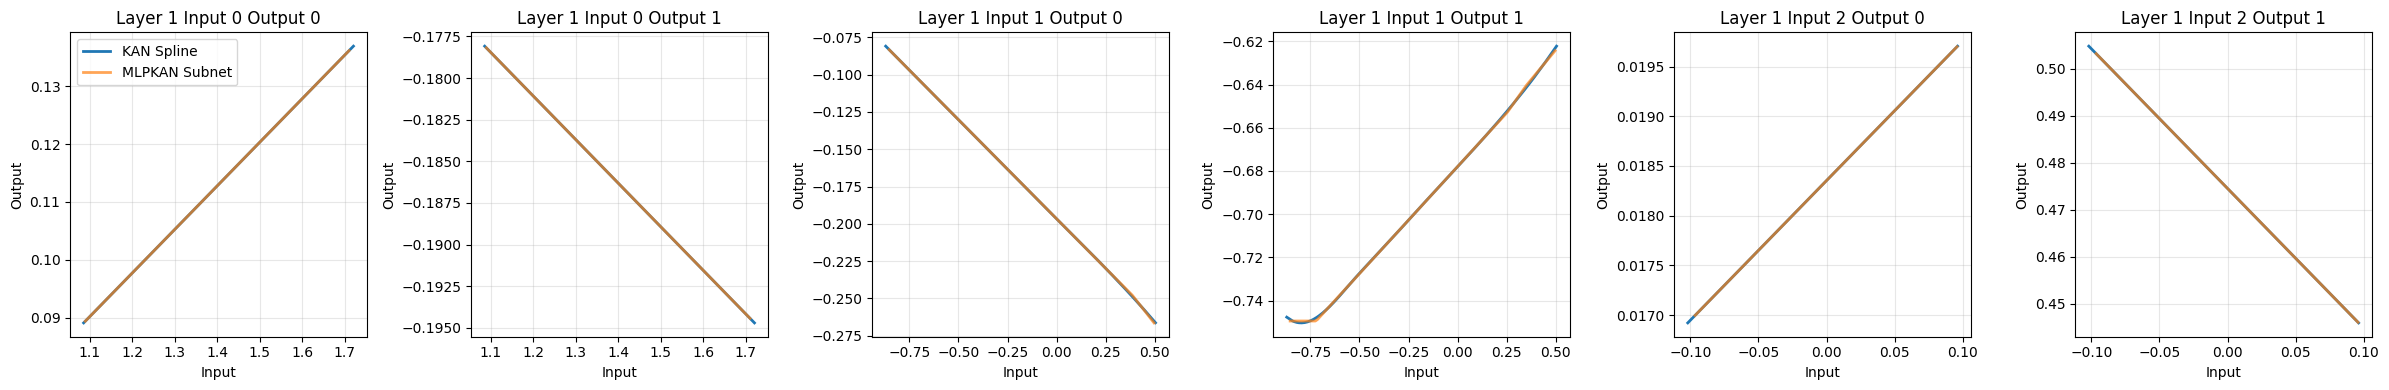

In [75]:

for i in range(len(model.layerSizes)-1):
    subnetworksi = model.layers[i]
    n_inputs = model.layerSizes[i]
    n_outputs = model.layerSizes[i+1]
    
    # Create a figure for this layer with 1 row and n_inputs*n_outputs columns (all horizontal)
    total_subplots = n_inputs * n_outputs
    fig, axes_flat = plt.subplots(1, total_subplots, figsize=(4*total_subplots, 4))
    
    # Handle case where there's only one subplot (axes won't be an array)
    if total_subplots == 1:
        axes_flat = [axes_flat]
    
    subplot_idx = 0
    for j in range(n_inputs):
        for k in range(n_outputs):
            subnet = subnetworksi[f'subnet_{j}_{k}']
            inputsMLPKAN = subnet.preacts.cpu().detach().numpy()
            outputsMLPKAN = subnet.postacts.cpu().detach().numpy()
            rankMLPKAN = np.argsort(inputsMLPKAN)
            inputsMLPKAN = inputsMLPKAN[rankMLPKAN]
            outputsMLPKAN = outputsMLPKAN[rankMLPKAN]
            
            inputskan = kan.spline_preacts[i][:,k,j].cpu().detach().numpy()
            outputskan = kan.spline_postacts[i][:,k,j].cpu().detach().numpy()
            rankkan = np.argsort(inputskan)
            inputskan = inputskan[rankkan]
            outputskan = outputskan[rankkan]

            ax = axes_flat[subplot_idx]
            ax.plot(inputskan, outputskan, label='KAN Spline', linewidth=2)
            ax.plot(inputsMLPKAN, outputsMLPKAN, label='MLPKAN Subnet', linewidth=2, alpha=0.7)
            ax.set_xlabel('Input')
            ax.set_ylabel('Output')
            ax.set_title(f'Layer {i} Input {j} Output {k}')
            ax.grid(True, alpha=0.3)
            if subplot_idx == 0:  # Add legend only to first subplot
                ax.legend()
            subplot_idx += 1
    
    plt.tight_layout()
    plt.show()
    plt.close()